# ANÁLISIS DEL CONSUMO DE GAS EN ESPAÑA

Este proyecto consiste en la modelización y predicción de la serie temporal del consumo total de gas natural en España. Para llevar a cabo este análisis se aplica la metodología iterativa de Box-Jenkins, orientada a ajustar modelos SARIMA capaces de capturar la dinámica de la serie y generar pronósticos precisos. Todo el desarrollo técnico y computacional se implementa en Python.

La metodología de Box-Jenkins se articula en tres etapas fundamentales previas a la predicción:

1. Identificación: Consiste en analizar las propiedades estadísticas de la serie temporal original para determinar si presenta componentes de tendencia y estacionalidad, así como evaluar su no estacionariedad en varianza y en media. Mediante inspección gráfica y contrastes formales (como el test de Bartlett), se evalúa la necesidad de transformaciones de estabilización de varianza (logaritmos). Posteriormente, se analiza el grado de diferenciación regular y estacional requerido y, a partir del análisis de las funciones de autocorrelación simple (ACF) y parcial (PACF), se proponen especificaciones tentativas.

2. Estimación y Validación: A continuación, se estiman los parámetros de los modelos candidatos comprobando su significación estadística. En este punto se incorporan criterios de validación cruzada y evaluación fuera de muestra (métricas como el MAPE) para medir la capacidad predictiva real de cada especificación.

3. Diagnosis de Residuos: Finalmente, se valida que el modelo seleccionado sea econométricamente adecuado. Para ello, se comprueba que sus residuos cumplan con las propiedades de ruido blanco débil: media nula, estacionariedad estricta, ausencia de correlación serial (mediante el test de Ljung-Box y correlogramas) y homocedasticidad condicional e incondicional (mediante el test ARCH-LM).

Una vez superadas satisfactoriamente estas fases, el modelo final se calibra para proyectar la demanda con sus correspondientes intervalos de confianza.

### Librerías a utilizar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import bartlett
import pmdarima as pm

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.holtwinters as ets
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_arch

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit

### Carga de datos

Cargamos el archivo CSV aplicando los delimitadores correspondientes y depuramos la estructura inicial para quedarnos con la serie agregada y construir un índice temporal mensual ('MS').

In [2]:
gas = pd.read_csv('data/consumo_gas.csv', sep = ';', thousands = '.')
gas.head()

,Año,Mes,TOTAL,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,2004,enero,27829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004,febrero,27420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2004,marzo,29592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004,abril,25025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2004,mayo,24062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Abrimos el CSV con Pandas y nos quedamos solo con el consumo total, para posteriormente añadir a mano las fechas.

In [3]:
gas = gas['TOTAL']
gas

0      27829
1      27420
2      29592
3      25025
4      24062
       ...  
266    27697
267    24046
268    24261
269    23778
270    27494
Name: TOTAL, Length: 271, dtype: int64

Generamos un rango de fechas con frecuencia mensual de inicio de mes (MS) que abarca todo el histórico disponible, desde enero de 2004 hasta julio de 2026, para establecerlo como índice temporal de la serie.

In [4]:
fechas = pd.date_range('2004-01-01','2026-07-01', 
               freq='MS').strftime("%Y-%m").tolist()
fechas = pd.Series(fechas)
fechas

0      2004-01
1      2004-02
2      2004-03
3      2004-04
4      2004-05
        ...   
266    2026-03
267    2026-04
268    2026-05
269    2026-06
270    2026-07
Length: 271, dtype: str

Juntamos en el DataFrame las columnas de meses y consumo.

In [5]:
df_gas = pd.concat([fechas, gas], axis = 1)

df_gas.columns = ['Month', 'gas_consumption']
df_gas.head()

,Month,gas_consumption
0,2004-01,27829
1,2004-02,27420
2,2004-03,29592
3,2004-04,25025
4,2004-05,24062


Finalmente, indicamos  la columna de los meses como el indice para que sea una serie temporal y poder realizar el análisis.

In [6]:
# Convertir en Serie Temporal
df_gas.set_index(['Month'], inplace = True)
df_gas.index = pd.to_datetime(df_gas.index)
df_gas.index.freq = 'MS'
df_gas

,gas_consumption
Month,
2004-01-01,27829
2004-02-01,27420
2004-03-01,29592
2004-04-01,25025
2004-05-01,24062
...,...
2026-03-01,27697
2026-04-01,24046
2026-05-01,24261


### Descripción de la serie

El objetivo de este proyecto consiste en modelizar y predecir la demanda de gas natural en España. La serie temporal ha sido obtenida de la Corporación de Reservas Estratégicas de Productos Petrolíferos (CORES). Contiene observaciones mensuales desde enero de 2004 hasta julio de 2026, y mide el consumo total del sistema nacional expresado en gigavatios-hora (GWh).

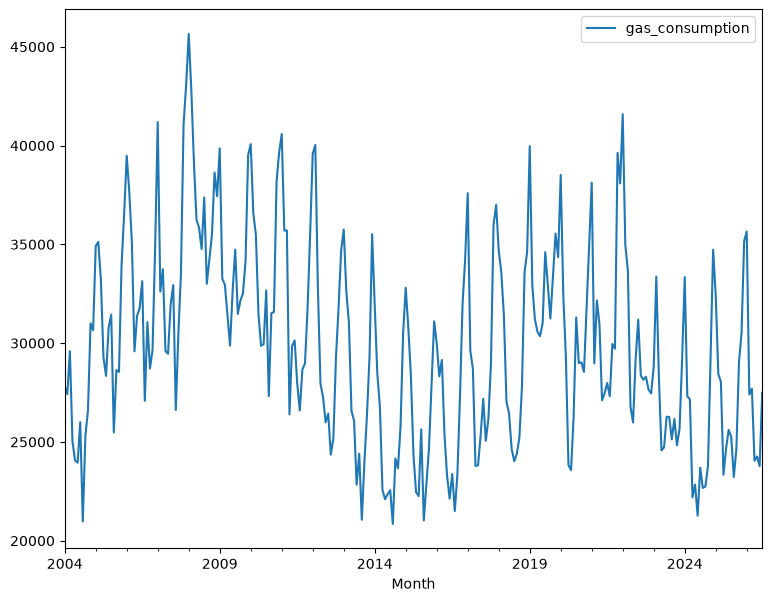

In [7]:
plt.rcParams["figure.figsize"] = (9,7)
df_gas.plot()
plt.savefig('../gas_serie_historica.png', dpi=300, bbox_inches='tight')
plt.show()

A simple vista, el gráfico permite extraer las siguientes conclusiones preliminares:

* Componente estacional recurrente: La serie presenta una estacionalidad anual marcada y sistemática $(s = 12)$, caracterizada por picos pronunciados en los meses de invierno debido al uso de calefacción y valles en los meses estivales.
* Estabilidad en varianza: La amplitud de las oscilaciones estacionales parece mantenerse razonablemente proporcional y constante a lo largo de todo el periodo, sugiriendo en primera instancia ausencia de heterocedasticidad severa (aspecto que se contrastará formalmente más adelante).
* Ausencia de tendencia determinista global pero con cambios de régimen: No se aprecia una tendencia lineal única y sostenida a lo largo de los 22 años, sino alternancias de ciclos y tendencias locales condicionadas por el contexto macroeconómico y geopolítico:
  1. *Fase expansiva (2004–2008):* Crecimiento continuo de la demanda hasta el inicio de la crisis financiera global de 2008, punto donde se inicia una contracción prolongada.
  2. *Recuperación y crisis energética (2014–2022):* Incremento gradual de la actividad hasta 2022, año en el que el estallido del conflicto en Ucrania y la consiguiente escalada histórica de los precios del gas provocaron un notable shock a la baja en el consumo.
  3. *Etapa reciente (2024–2026):* Rebote paulatino de la demanda, aunque sujeta a la volatilidad e incertidumbre geopolítica internacional.

La presencia simultánea de estacionalidad anual y oscilaciones de media en el tiempo anticipa la necesidad de aplicar diferenciación regular y estacional para transformar la serie en un proceso estacionario.


## Modelización Box-Jenkins

Una vez exploradas las características descriptivas de la serie, se procede a aplicar la metodología de Box-Jenkins para determinar la estructura estocástica del proceso y seleccionar el modelo óptimo de predicción.

### 1. Identificación

#### 1.1 Estabilización de la varianza (Transformación de la serie)
El primer paso consiste en determinar si la serie es estacionaria en varianza (homocedástica) o si, por el contrario, la dispersión varía con el nivel medio exigiendo una transformación no lineal (como el logaritmo natural).

Para contrastarlo de manera rigurosa, se implementa el test de Bartlett, cuya hipótesis nula plantea la igualdad de varianzas entre los diferentes subperiodos anuales de la serie:
* $H_0$: Las submuestras anuales presentan la misma varianza $(\sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$, homocedasticidad).
* $H_1$: Al menos un periodo presenta una varianza estadísticamente diferente (heterocedasticidad).

In [8]:
def bartlett_test(series):
    # Convertir a array plano de NumPy tipo float
    arr = series.values.astype(float)
    
    # Cortamos para que solo haya bloques completos de 12 meses
    n_years = len(arr) // 12
    y = arr[:n_years * 12]

    # Dividir en matriz de [años x 12 meses]
    matriz_nivel = y.reshape(n_years, 12)
    matriz_log = np.log(y).reshape(n_years, 12)
    
    #Test oficial de SciPy
    stat_nivel, p_nivel = bartlett(*matriz_nivel)
    stat_log, p_log = bartlett(*matriz_log)

    results = pd.DataFrame({
                'nivel': [stat_nivel, p_nivel],
                'log': [stat_log, p_log]
             }, index=['stat', 'prob'])
    print(results)

In [9]:
bartlett_test(df_gas['gas_consumption'])

          nivel        log
stat  17.212923  20.488644
prob   0.698121   0.490527


El contraste arroja los siguientes resultados:
* Serie en niveles: estadístico $\chi^2 = 17.21$, con un $p$-valor asociado de $0.698$.
* Serie en logaritmos: estadístico $\chi^2 = 20.49$, con un $p$-valor asociado de $0.491$.

Dado que en la serie en niveles el $p$-valor supera con holgura el nivel de significación habitual $(\alpha = 0.05)$, no se rechaza la hipótesis nula de homocedasticidad. Por consiguiente, la variabilidad se mantiene estable en el tiempo y no se requiere la aplicación de logaritmos, permitiendo continuar el modelado directamente con la serie en sus unidades originales (GWh).

#### 1.2 Orden de integración y estacionariedad en media

Una vez validada la estabilidad de la varianza con la serie en niveles, el siguiente paso consiste en determinar el orden de integración del proceso, tanto regular $(d)$ como estacional $(D)$. El objetivo es identificar las diferencias necesarias para transformar la serie original en un proceso estacionario en media alrededor de un valor constante.

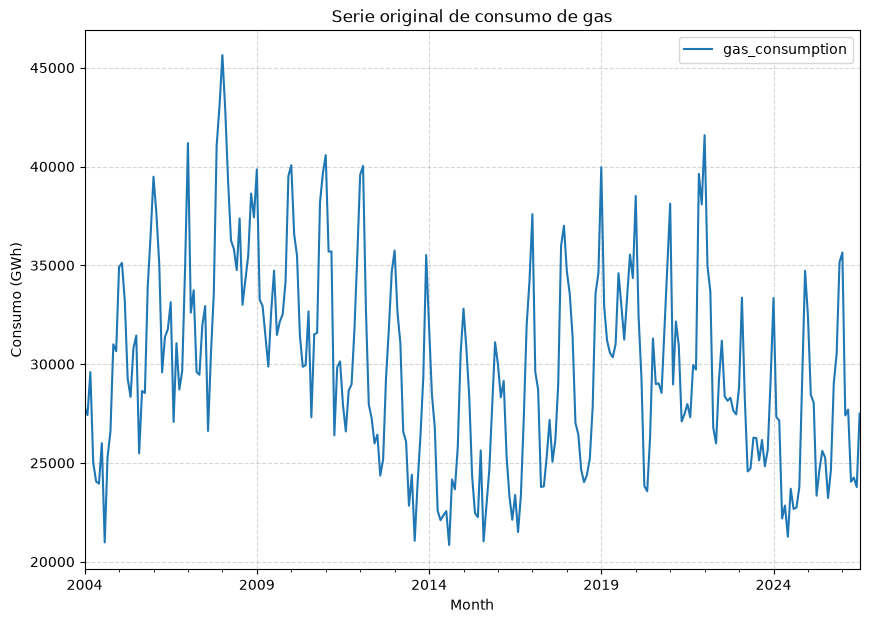

In [10]:
df_gas.plot(figsize=(10, 7))
plt.title("Serie original de consumo de gas")
plt.ylabel("Consumo (GWh)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  

La serie en niveles exhibe oscilaciones periódicas persistentes y cambios en su nivel medio a lo largo del tiempo, evidenciando una clara falta de estacionariedad. Para corroborar formalmente esta no estacionariedad se analizan a continuación las funciones de autocorrelación simple (ACF) y parcial (PACF).

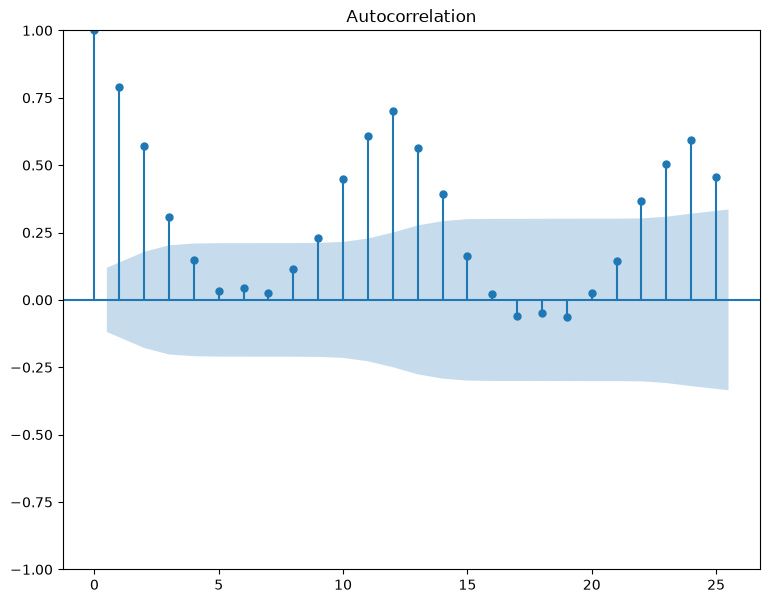

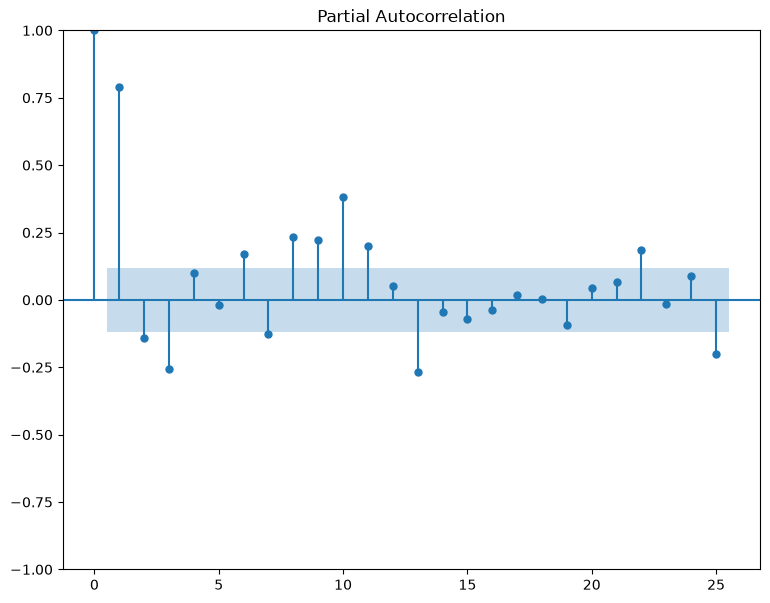

In [11]:
plot_acf(df_gas.dropna(inplace = False))
plot_pacf(df_gas.dropna(inplace = False))
plt.show()

El correlograma refleja claramente que la serie en niveles no es estacionaria: el ACF muestra una persistencia lenta en los primeros retardos y un patrón ondulante con picos muy pronunciados fuera de las bandas de confianza en los múltiplos de 12 (lags 12 y 24 con $\rho \approx 0.7$ y $0.6$), mientras que el PACF presenta un retardo 1 dominante $(\approx 0.8)$ junto a cortes significativos alrededor del ciclo anual. Este comportamiento confirma la necesidad imperativa de aplicar una diferencia estacional $(\Delta_{12})$ .

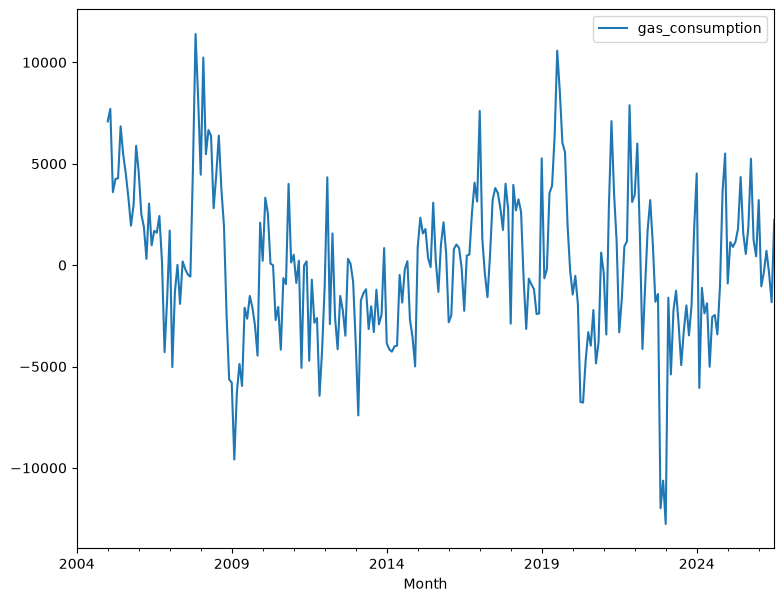

In [12]:
gas_diff_12 = df_gas.diff(periods = 12)
gas_diff_12.plot()
plt.show()

Tras aplicar la diferencia estacional $(\Delta_{12})$, se elimina el patrón periódico cíclico anual. Sin embargo, persisten oscilaciones locales y cierta inercia en la serie que suscitan dudas sobre su estacionariedad en media. Para verificar formalmente la presencia de una raíz unitaria regular remanente, se aplica el contraste de Dickey-Fuller Aumentado (ADF).

In [13]:
def test_stationarity(timeseries, reg='c'):
    # Test Augmented Dickey-Fuller
    dftest = adfuller(timeseries, autolag='AIC', regression=reg)
    dfoutput = pd.Series(
        [dftest[0], dftest[1], int(dftest[2]), int(dftest[3])],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    )
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
        
    print('Results of Dickey-Fuller Test:')
    # Mostrar con 4 decimales limpios
    print(dfoutput.apply(lambda x: f"{x:.4f}" if isinstance(x, float) else f"{x}"))

In [14]:
test_stationarity(gas_diff_12.dropna(), reg = 'ct') # ct porque presenta tendencias todavía el grafico

Results of Dickey-Fuller Test:
Test Statistic                  -3.2309
p-value                          0.0784
#Lags Used                      16.0000
Number of Observations Used    242.0000
Critical Value (1%)             -3.9967
Critical Value (5%)             -3.4288
Critical Value (10%)            -3.1378
dtype: str


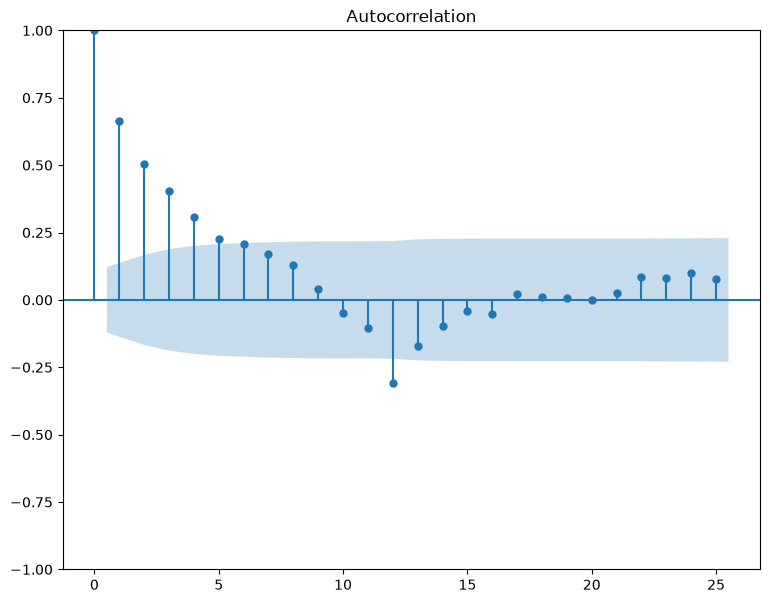

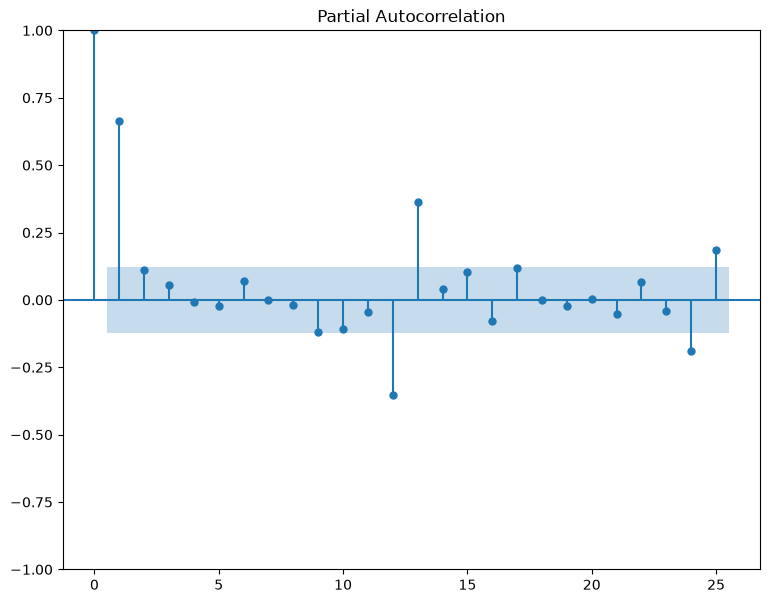

In [15]:
plot_acf(gas_diff_12.dropna(inplace = False))
plot_pacf(gas_diff_12.dropna(inplace = False))
plt.show()

Dado que el $p$-valor obtenido (0.0784) es superior al nivel de significación estándar del $5\%$ $(\alpha = 0.05)$, no se puede rechazar la hipótesis nula de raíz unitaria. La persistencia observada en los primeros retardos del correlograma ratifica la no estacionariedad en media regular, justificando formalmente la aplicación de una primera diferencia regular $(\Delta)$.

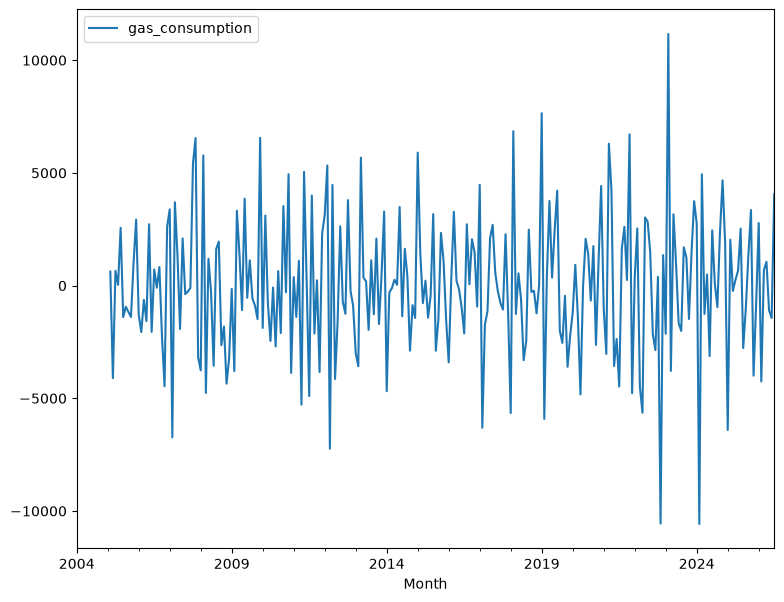

In [16]:
gas_diff_1_12 = gas_diff_12.diff(periods = 1)
gas_diff_1_12.plot()
plt.show()

Tras aplicar la primera diferencia regular sobre la serie desestacionalizada $(\Delta \Delta_{12})$, la serie fluctúa de manera homogénea en torno a cero sin tendencias aparentes. A continuación, se aplica el test ADF con constante (`reg='c'`) para validar estadísticamente la estacionariedad.

In [17]:
test_stationarity(gas_diff_1_12.dropna(), reg = 'c') # Porque ya no presenta tendencias

Results of Dickey-Fuller Test:
Test Statistic                  -6.8222
p-value                          0.0000
#Lags Used                      15.0000
Number of Observations Used    242.0000
Critical Value (1%)             -3.4577
Critical Value (5%)             -2.8736
Critical Value (10%)            -2.5732
dtype: str


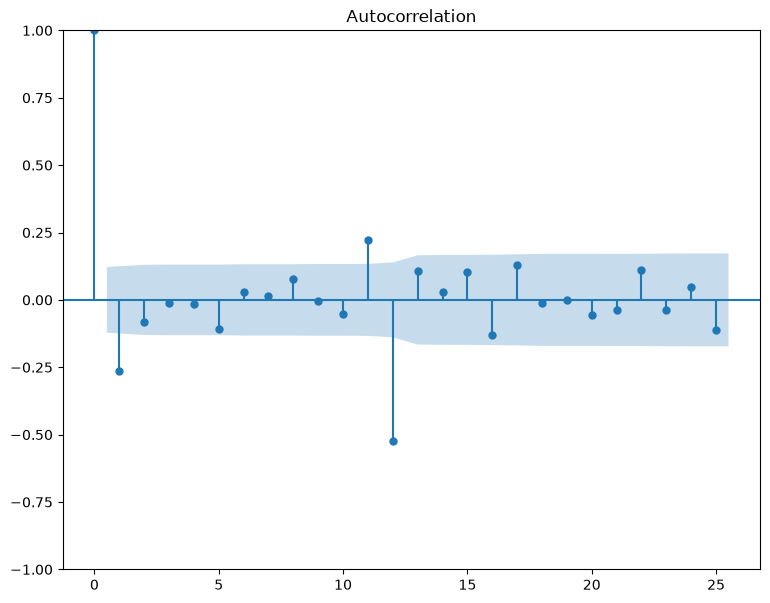

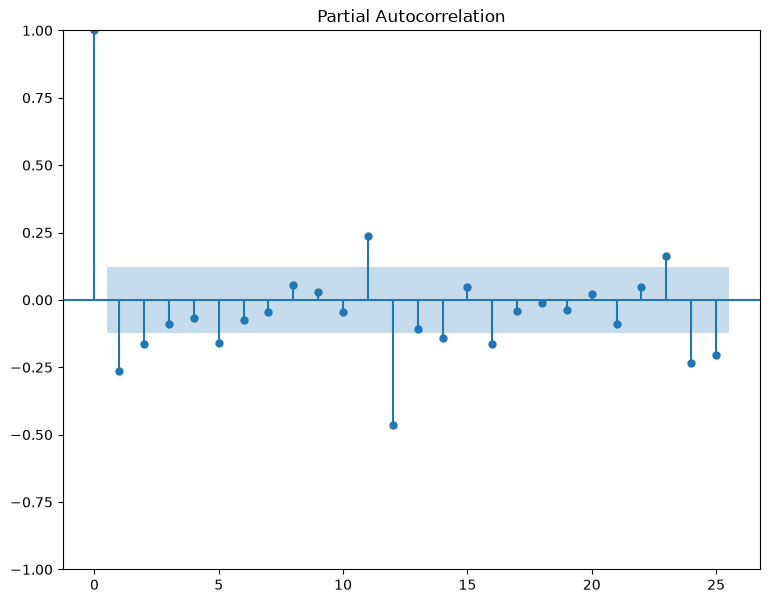

In [18]:
plot_acf(gas_diff_1_12.dropna(inplace = False))
plot_pacf(gas_diff_1_12.dropna(inplace = False))
plt.show()

Tras aplicar una diferencia regular y una estacional $(d = 1, D = 1)$, la serie alcanza la estacionariedad. El ACF muestra un corte nítido y negativo en el retardo 1 y un pico pronunciado en el retardo 12 que se anula en el retardo 24, señalando la presencia de componentes de medias móviles regular y estacional $(q = 1, Q = 1)$. Por su parte, el comportamiento amortiguado del PACF respalda la formulación del modelo canónico $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ como hipótesis principal de Box-Jenkins, planteando variantes con términos autorregresivos ($p = 1$ o $P = 1$) para contrastar en la etapa de estimación.

### 2. Estimación

Como estrategia de selección rigurosa frente a la ambigüedad observada en los retardos cruzados, se adopta un enfoque de lo General a lo Específico. En primer lugar, se formulan las especificaciones candidatas estimadas sobre la serie histórica completa (2004–2026), tomando como referencia inicial un modelo general $\text{SARIMA}(1, 1, 1) \times (1, 1, 1)_{12}$. A partir de este ajuste, se aplica una eliminación hacia atrás (backward elimination) para suprimir coeficientes no estadísticamente significativos $(p > 0.05)$, priorizando la parsimonia estructural, la minimización de los criterios de información (AIC/BIC) y la ausencia de autocorrelación en los residuos.

Asimismo, para complementar la metodología clásica de Box-Jenkins y evitar depender de una única partición estática fuera de muestra, la capacidad predictiva se evalúa mediante una validación temporal secuencial (walk-forward cross-validation) con reentrenamiento periódico. El algoritmo particiona la serie de forma dinámica a lo largo de una ventana de prueba multianual, ajustando los parámetros en cada corte temporal con los datos observados hasta ese momento y proyectando horizontes sucesivos de 12 meses completos $(s = 12)$. De este modo, la selección final no descansa exclusivamente en los contrastes de significación paramétrica dentro de muestra, sino en la consistencia y estabilidad del error relativo empírico (MAPE medio) obtenido a través de múltiples ciclos estacionales fuera de muestra.

#### 2.1 Estimación del modelo general de partida: SARIMA$(1, 1, 1)(1, 1, 1)_{12}$

Siguiendo la estrategia de lo general a lo específico, se ajusta inicialmente la especificación sobredimensionada que incorpora tanto términos autorregresivos como de medias móviles regulares y estacionales sobre la totalidad de la muestra histórica disponible ($T = 271$, 2004–2026).

In [19]:
arima1 = SARIMAX(df_gas['gas_consumption'], 
                order = (1, 1, 1), 
                seasonal_order =(1, 1, 1, 12))
  
arima_1 = arima1.fit()
arima_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  271
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2366.415
Date:                            Tue, 29 Sep 2026   AIC                           4742.829
Time:                                    17:23:16   BIC                           4760.594
Sample:                                01-01-2004   HQIC                          4749.972
                                     - 07-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4119      0.194      2.122      0.034       0.031       0.792
ma.L1         -0.6406      0.161     -3.983      0.000      -0.956      -0.325
ar.S.L12       0.0719      0.060      1.205      0.228      -0.045       0.189
ma.S.L12      -0.8197      0.045    -18.264      0.000      -0.908      -0.732
sigma2      5.179e+06      4e+05     12.940      0.000    4.39e+06    5.96e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):                11.86
Prob(Q):                              0.52   Prob(JB):                         0.00
Heteroskedasticity (H):               0.93   Skew:                             0.03
Prob(H) (two-sided):                  0.73   Kurtosis:                         4.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Del resumen de la estimación se extraen los siguientes contrastes de significación individual (con un nivel de significación del 5%):

* Términos de medias móviles: Resultan altamente significativos tanto en la parte regular (`ma.L1`, $p < 0.001$) como en la estacional (`ma.S.L12`, $p < 0.001$).
* Término autorregresivo regular (`ar.L1`): Es estadísticamente significativo al 5% ($p\text{-valor} = 0.034$, con estadístico $z = 2.122$).
* Término autorregresivo estacional (`ar.S.L12`): No resulta estadísticamente significativo ($p\text{-valor} = 0.228$, marcadamente superior a $\alpha = 0.05$).

Criterios de información obtenidos: AIC = 4742.829 y BIC = 4760.594

Asimismo, el diagnóstico de los residuos confirma la estabilidad de la varianza: el test de heterocedasticidad de Harvey $(H)$ arroja un estadístico de 0.93, lo que evidencia que la dispersión de los errores se mantiene constante a lo largo de todo el horizonte muestral y valida el modelado de la serie en niveles.

A continuación, se evalúa la estabilidad predictiva mediante una validación temporal walk-forward con ventana expansiva (5 folds de 12 meses). En cada iteración se reestima el modelo y se proyecta a un año vista, contrastando la consistencia del MAPE en diferentes contextos temporales.

In [20]:
# Ventana expandida evaluando tramos de 12 meses (horizonte anual)
tscv = TimeSeriesSplit(n_splits=5, test_size=12)
mapes = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_gas)):
    y_tr = df_gas['gas_consumption'].iloc[train_idx].asfreq('MS')
    y_te = df_gas['gas_consumption'].iloc[test_idx].asfreq('MS')
    
    # Ajuste del modelo 
    mod = SARIMAX(y_tr, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    res = mod.fit(disp=False)
    
    # Pronóstico fuera de muestra
    fc = res.forecast(steps=len(y_te))
    
    mape = np.mean(np.abs((y_te - fc) / y_te)) * 100
    mapes.append(mape)
    print(f"Fold {fold + 1} - Período: {y_te.index[0].strftime('%Y-%m')} a {y_te.index[-1].strftime('%Y-%m')} | MAPE: {mape:.2f}%")

print(f"\nMAPE promedio en validación walk-forward: {np.mean(mapes):.2f}% (+/- {np.std(mapes):.2f}%)")

Fold 1 - Período: 2021-08 a 2022-07 | MAPE: 7.97%


Fold 2 - Período: 2022-08 a 2023-07 | MAPE: 18.93%


Fold 3 - Período: 2023-08 a 2024-07 | MAPE: 6.67%


Fold 4 - Período: 2024-08 a 2025-07 | MAPE: 9.25%


Fold 5 - Período: 2025-08 a 2026-07 | MAPE: 4.74%

MAPE promedio en validación walk-forward: 9.51% (+/- 4.94%)


Análisis de Resultados: Validación Walk-Forward (Ventana Expansiva):

* Fold 1 (2021-08 a 2022-07) | MAPE: 7.97%: Nivel de error bajo en el periodo previo al impacto del conflicto energético.
* Fold 2 (2022-08 a 2023-07) | MAPE: 18.93%: El error aumenta notablemente. Refleja el momento del shock de demanda derivado de la crisis energética y las medidas de ahorro, el cual no podía ser anticipado por el histórico previo de entrenamiento.
* Fold 3 (2023-08 a 2024-07) | MAPE: 6.67%: Una vez que los datos del nuevo régimen ingresan al entrenamiento, el modelo recupera su capacidad predictiva.
* Fold 4 (2024-08 a 2025-07) | MAPE: 9.25%: Desempeño estable dentro del nuevo rango de consumo.
* Fold 5 (2025-08 a 2026-07) | MAPE: 4.74% Ajuste óptimo en el ciclo anual más reciente.

El MAPE promedio obtenido es de 9.51% (± 4.94%). Los resultados muestran que, salvo en el periodo puntual del quiebre estructural (Fold 2 con ~19%), el modelo mantiene errores consistentes de un solo dígito a lo largo de los distintos cortes temporales. A pesar del buen rendimiento predictivo, el término estacional `ar.S.L12` no resultó significativo, por lo que se procede a estimar el siguiente modelo eliminando dicho parámetro.

#### 2.2 Estimación del modelo simplificado: $\text{SARIMA}(1,1,1)(0,1,1)_{12}$

In [21]:
arima2 = SARIMAX(df_gas['gas_consumption'], 
                order = (1, 1, 1), 
                seasonal_order =(0, 1, 1, 12))
  
arima_2 = arima2.fit()
arima_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  271
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2366.762
Date:                            Tue, 29 Sep 2026   AIC                           4741.524
Time:                                    17:23:43   BIC                           4755.736
Sample:                                01-01-2004   HQIC                          4747.239
                                     - 07-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4109      0.192      2.142      0.032       0.035       0.787
ma.L1         -0.6415      0.159     -4.030      0.000      -0.954      -0.329
ma.S.L12      -0.7730      0.041    -18.719      0.000      -0.854      -0.692
sigma2       5.21e+06   3.92e+05     13.278      0.000    4.44e+06    5.98e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                14.81
Prob(Q):                              0.58   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                             0.04
Prob(H) (two-sided):                  0.67   Kurtosis:                         4.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Tras suprimir el término autorregresivo estacional (`ar.S.L12`), todos los coeficientes remanentes resultan estadísticamente significativos al $5\%$ (incluido el término autorregresivo regular `ar.L1` con $p = 0.032$). 

Además, se produce una reducción en los criterios de información penalizada:
* AIC: desciende de $4742.829$ a $4741.524$.
* BIC: se reduce de $4760.594$ a $4755.736$.

El diagnóstico de los residuos también confirma la estabilidad de la varianza: el test de heterocedasticidad de Harvey $(H)$ arroja un estadístico de 0.91, lo que evidencia que la dispersión de los errores se mantiene constante a lo largo de todo el horizonte muestral y valida el modelado de la serie en niveles.

Esta mejora ratifica que la eliminación del parámetro innecesario genera una especificación más eficiente dentro de muestra. A continuación, se evalúa su desempeño fuera de muestra.

In [22]:
mapes = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_gas)):
    y_tr = df_gas['gas_consumption'].iloc[train_idx].asfreq('MS')
    y_te = df_gas['gas_consumption'].iloc[test_idx].asfreq('MS')
    
    # Ajuste del modelo 
    mod = SARIMAX(y_tr, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
    res = mod.fit(disp=False)
    
    # Pronóstico fuera de muestra
    fc = res.forecast(steps=len(y_te))
    
    mape = np.mean(np.abs((y_te - fc) / y_te)) * 100
    mapes.append(mape)
    print(f"Fold {fold + 1} - Período: {y_te.index[0].strftime('%Y-%m')} a {y_te.index[-1].strftime('%Y-%m')} | MAPE: {mape:.2f}%")

print(f"\nMAPE promedio en validación walk-forward: {np.mean(mapes):.2f}% (+/- {np.std(mapes):.2f}%)")

Fold 1 - Período: 2021-08 a 2022-07 | MAPE: 7.98%


Fold 2 - Período: 2022-08 a 2023-07 | MAPE: 18.97%


Fold 3 - Período: 2023-08 a 2024-07 | MAPE: 6.72%


Fold 4 - Período: 2024-08 a 2025-07 | MAPE: 9.55%


Fold 5 - Período: 2025-08 a 2026-07 | MAPE: 5.05%

MAPE promedio en validación walk-forward: 9.65% (+/- 4.89%)


Conclusión: Modelo SARIMA $(1, 1, 1)(0, 1, 1)_{12}$ (Sin término $AR$ estacional)

* Fold 1 (2021-08 a 2022-07) | MAPE: 7.98%: Buen ajuste inicial previo a la fase crítica del choque energético.
* Fold 2 (2022-08 a 2023-07) | MAPE: 18.97%: Absorbe el impacto directo del quiebre estructural de 2022 sin anticiparlo, arrojando el pico de error previsto.
* Fold 3 (2023-08 a 2024-07) | MAPE: 6.72%: Rápida corrección y estabilización tras incorporar datos del nuevo nivel de consumo.
* Fold 4 (2024-08 a 2025-07) | MAPE: 9.55%: Ajuste sólido en el periodo post-crisis.
* Fold 5 (2025-08 a 2026-07) | MAPE: 5.05%: Error mínimo y óptima precisión en el ciclo más reciente.

Evaluación:
El MAPE promedio obtenido es de 9.65% (± 4.89%). Al retirar el término `ar.S.L12` (que no resultaba estadísticamente significativo en la estimación previa), el modelo mantiene una capacidad predictiva prácticamente idéntica (9.65% frente a 9.51%) con una ligera reducción en la dispersión del error (± 4.89% frente a ± 4.94%).

#### 2.3 Estimación del modelo de propuesta inicial: $\text{SARIMA}(0,1,1)(0,1,1)_{12}$

In [23]:
arima3 = SARIMAX(df_gas['gas_consumption'], 
                order = (0, 1, 1), 
                seasonal_order =(0, 1, 1, 12))
  
arima_3 = arima3.fit()
arima_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  271
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2368.037
Date:                            Tue, 29 Sep 2026   AIC                           4742.074
Time:                                    17:24:00   BIC                           4752.733
Sample:                                01-01-2004   HQIC                          4746.360
                                     - 07-01-2026                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2449      0.054     -4.559      0.000      -0.350      -0.140
ma.S.L12      -0.7834      0.039    -20.308      0.000      -0.859      -0.708
sigma2      5.268e+06   3.88e+05     13.590      0.000    4.51e+06    6.03e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                19.49
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                             0.06
Prob(H) (two-sided):                  0.82   Kurtosis:                         4.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

En esta especificación $\text{SARIMA}(0,1,1)(0,1,1)_{12}$:
* Todos los coeficientes resultan estadísticamente significativos con un nivel de confianza superior al $99\%$ ($p\text{-valor} < 0.001$).
* Aunque el AIC experimenta un leve incremento respecto al Modelo 2 (de $4741.524$ a $4742.074$), el criterio bayesiano alcanza su valor mínimo global: $\text{BIC} = 4752.733$ (frente a los $4755.736$ del Modelo 2).

Por último, para este tercer modelo el diagnóstico de los residuos también confirma la estabilidad de la varianza: el test de heterocedasticidad de Harvey $(H)$ arroja un estadístico de 0.95, lo que evidencia que la dispersión de los errores se mantiene constante a lo largo de todo el horizonte muestral y valida el modelado de la serie en niveles.

El BIC penaliza con mayor severidad la inclusión de parámetros adicionales, confirmando que prescindir del término autorregresivo regular simplifica la estructura del modelo sin incurrir en pérdida de capacidad explicativa dentro de muestra. A continuación, se evalúa su desempeño fuera de muestra.

In [24]:
mapes = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_gas)):
    y_tr = df_gas['gas_consumption'].iloc[train_idx].asfreq('MS')
    y_te = df_gas['gas_consumption'].iloc[test_idx].asfreq('MS')
    
    # Ajuste del modelo Airline
    mod = SARIMAX(y_tr, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
    res = mod.fit(disp=False)
    
    # Pronóstico fuera de muestra
    fc = res.forecast(steps=len(y_te))
    
    mape = np.mean(np.abs((y_te - fc) / y_te)) * 100
    mapes.append(mape)
    print(f"Fold {fold + 1} - Período: {y_te.index[0].strftime('%Y-%m')} a {y_te.index[-1].strftime('%Y-%m')} | MAPE: {mape:.2f}%")

print(f"\nMAPE promedio en validación walk-forward: {np.mean(mapes):.2f}% (+/- {np.std(mapes):.2f}%)")

Fold 1 - Período: 2021-08 a 2022-07 | MAPE: 8.73%


Fold 2 - Período: 2022-08 a 2023-07 | MAPE: 19.52%


Fold 3 - Período: 2023-08 a 2024-07 | MAPE: 6.86%


Fold 4 - Período: 2024-08 a 2025-07 | MAPE: 10.05%


Fold 5 - Período: 2025-08 a 2026-07 | MAPE: 5.08%

MAPE promedio en validación walk-forward: 10.05% (+/- 5.03%)


Conclusión: Modelo Airline Puro SARIMA $(0, 1, 1) \times (0, 1, 1)_{12}$

* Fold 1 (2021-08 a 2022-07) | MAPE: 8.73%: Desempeño predictivo estable en el ciclo previo al choque de precios.
* Fold 2 (2022-08 a 2023-07) | MAPE: 19.52%: Recoge el impacto pleno del quiebre estructural de 2022 fuera de muestra.
* Fold 3 (2023-08 a 2024-07) | MAPE: 6.86%: Rápida convergencia y recuperación de precisión una vez asimilado el nuevo nivel de demanda.
* Fold 4 (2024-08 a 2025-07) | MAPE: 10.05%: Comportamiento regular en el entorno postcrisis.
* Fold 5 (2025-08 a 2026-07) | MAPE: 5.08%: Ajuste preciso en la ventana anual más reciente.

Evaluación y Principio de Parsimonia:
El MAPE promedio obtenido es de 10.05% (± 5.03%). Esta especificación corresponde al clásico modelo Airline de Box-Jenkins (únicamente dos parámetros de medias móviles: regular y estacional). Con solo dos coeficientes a estimar, logra un rendimiento prácticamente equivalente al de modelos con más términos autorregresivos (10.05% vs 9.65% y 9.58%), consolidándose como la opción de máxima parsimonia, menor riesgo de sobreajuste y mayor interpretabilidad teórica.

Con el propósito de validar de manera exhaustiva las especificaciones analizadas manualmente, se ejecuta a continuación el algoritmo `auto_arima` de *pmdarima* mediante optimización paso a paso (*stepwise*) bajo el criterio AIC.

In [25]:

# Ajustamos modelo arima step-wise con métrica AIC para la serie de vuelos
arima_auto = pm.auto_arima(df_gas['gas_consumption'], start_p=1, start_q=1,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=5, max_q=5, # maximum p and q
                      m=12,              # frequency of series
                      d=1,           # let model determine 'd'
                      seasonal=True,   # No Seasonality
                      #start_P=None, 
                      D=1, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(arima_auto.summary())


Performing stepwise search to minimize aic


 ARIMA(1,1,1)(1,1,1)[12]             : AIC=4742.829, Time=3.71 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=4873.787, Time=0.11 sec


 ARIMA(1,1,0)(1,1,0)[12]             : AIC=4806.005, Time=0.50 sec


 ARIMA(0,1,1)(0,1,1)[12]             : AIC=4742.074, Time=2.12 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=4855.284, Time=0.15 sec


 ARIMA(0,1,1)(1,1,1)[12]             : AIC=4743.210, Time=4.76 sec


...

 ARIMA(1,1,2)(0,1,1)[12]             : AIC=4745.968, Time=5.01 sec


 ARIMA(0,1,2)(0,1,1)[12]             : AIC=4742.429, Time=2.05 sec


 ARIMA(2,1,0)(0,1,1)[12]             : AIC=4743.420, Time=2.43 sec


 ARIMA(2,1,2)(0,1,1)[12]             : AIC=inf, Time=5.38 sec


 ARIMA(1,1,1)(0,1,1)[12] intercept   : AIC=4741.650, Time=4.60 sec

Best model:  ARIMA(1,1,1)(0,1,1)[12]          
Total fit time: 71.753 seconds
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  271
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2366.762
Date:                            Tue, 29 Sep 2026   AIC                           4741.524
Time:                                    17:25:23   BIC                           4755.736
Sample:                                01-01-2004   HQIC                          4747.239
                                     - 07-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

#### 2.4 Comparativa final y selección del modelo óptimo

El procedimiento automatizado `auto_arima` selecciona como especificación preferida bajo la minimización estricta de AIC el modelo SARIMA$(1, 1, 1)(0, 1, 1)_{12}$ (idéntico a nuestro Modelo 2).

No obstante, al confrontar de forma multidimensional las tres especificaciones candidatas:

1. SARIMA$(1, 1, 1)(1, 1, 1)_{12}$ (Modelo 1): Aunque obtiene el menor error fuera de muestra en el último ciclo anual ($\text{MAPE} = 4.74\%$, con promedio walk-forward de $9.51\%$), incluye un parámetro estacional (`ar.S.L12`) no significativo $(p = 0.228)$, vulnerando el criterio de significación individual.
2. SARIMA$(1, 1, 1)(0, 1, 1)_{12}$ (Modelo 2): Minimiza el AIC $(4741.524)$ y logra un $\text{MAPE} = 5.05\%$, con promedio walk-forward de $9.65\%$, pero presenta un criterio de información bayesiano superior $(\text{BIC} = 4755.736)$.
3. SARIMA$(0, 1, 1)(0, 1, 1)_{12}$ (Modelo 3 - Airline Model): Todos sus parámetros son altamente significativos ($p < 0.001$), su capacidad predictiva es prácticamente indistinguible del Modelo 2 ($\text{MAPE} = 5.08\%$, con promedio walk-forward de $10.05\%$) y minimiza el criterio de información bayesiano ($\text{BIC} = 4752.733$).

Bajo el principio de parsimonia, que prioriza la estructura más simple y robusta ante desempeños predictivos equivalentes, se selecciona formalmente el Modelo 3: SARIMA$(0, 1, 1)(0, 1, 1)_{12}$  con formulación teórica:

$$(1 - B)(1 - B^{12})y_t = (1 - \theta_1 B)(1 - \Theta_1 B^{12})\epsilon_t$$

Donde:
* $B$ es el operador de retardo ($B^k y_t = y_{t-k}$).
* $(1 - B)(1 - B^{12})$ representa el filtro de doble diferenciación aplicada (regular y estacional).
* $\theta_1$ es el parámetro de media móvil regular ($\text{MA}_1$).
* $\Theta_1$ es el parámetro de media móvil estacional ($\text{SMA}_{12}$).
* $\epsilon_t$ representa las perturbaciones estocásticas o ruido blanco ($\epsilon_t \sim \text{iid}(0, \sigma^2)$).

No obstante, antes de proceder al diagnóstico exhaustivo de los residuos y a la generación de las predicciones definitivas, se evaluará la incorporación de una variable ficticia (dummy) para capturar el shock estructural derivado de la guerra de Ucrania.

In [26]:
# Crear la variable dummy directamente en el DataFrame original
df_gas['dummy_ucrania'] = (df_gas.index >= '2022-03-01').astype(int)
df_gas

,gas_consumption,dummy_ucrania
Month,,
2004-01-01,27829,0
2004-02-01,27420,0
2004-03-01,29592,0
2004-04-01,25025,0
2004-05-01,24062,0
...,...,...
2026-03-01,27697,1
2026-04-01,24046,1
2026-05-01,24261,1


In [27]:
arima_dummy = SARIMAX(df_gas['gas_consumption'],
                      exog = df_gas['dummy_ucrania'],
                order = (0, 1, 1), 
                seasonal_order =(0, 1, 1, 12))
  
arima_dummy = arima_dummy.fit()
arima_dummy.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    gas_consumption   No. Observations:                  271
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2367.939
Date:                            Tue, 29 Sep 2026   AIC                           4743.879
Time:                                    17:25:25   BIC                           4758.091
Sample:                                01-01-2004   HQIC                          4749.593
                                     - 07-01-2026                                         
Covariance Type:                              opg                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
dummy_ucrania  -356.9118   4930.122     -0.072      0.942      -1e+04    9305.950
ma.L1            -0.2466      0.054     -4.587      0.000      -0.352      -0.141
ma.S.L12         -0.7829      0.039    -20.207      0.000      -0.859      -0.707
sigma2         5.264e+06   3.87e+05     13.599      0.000    4.51e+06    6.02e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                19.59
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.95   Skew:                             0.06
Prob(H) (two-sided):                  0.81   Kurtosis:                         4.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
from statsmodels.stats.diagnostic import breaks_cusumolsresid

# Test de estabilidad sobre los residuos del modelo
cusum_stat, p_val, crit_bounds = breaks_cusumolsresid(arima_3.resid)
print(f"P-valor CUSUM: {p_val:.4f}")

P-valor CUSUM: 0.2245


Como se observa en los resultados de la estimación, la variable de intervención no resulta estadísticamente significativa ($\hat{\beta} = -356.91$, $p\text{-valor} = 0.942$), incrementando además los criterios de penalización ($\text{AIC} = 4743.879$ y $\text{BIC} = 4758.091$). Esto confirma que la estructura de doble diferenciación del modelo $\text{SARIMA}(0, 1, 1)(0, 1, 1)_{12}$ absorbe eficazmente la alteración en el nivel de demanda sin requerir parámetros exógenos adicionales. 

Asimismo, el test CUSUM sobre los residuos del Modelo 3 arroja un $p\text{-valor} = 0.2245$, por lo que no se rechaza la hipótesis nula de estabilidad estructural al 5% de significación. En consecuencia, se ratifica la especificación univariante del Modelo 3 como la definitiva para llevar a cabo el diagnóstico de residuos y las previsiones finales.

### 3. Diagnosis del Modelo Seleccionado

Previamente a la generación de predicciones definitivas, se somete el modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ a una etapa exhaustiva de diagnosis residual para comprobar si las perturbaciones estimadas satisfacen las propiedades de un proceso de ruido blanco:

1. Media nula $(\mu_\varepsilon \approx 0)$: Garantiza la insesgadez de las estimaciones.
2. Incorrelación serial: Se evalúa inicialmente mediante la inspección visual del correlograma (ACF) para constatar la ausencia de autocorrelaciones significativas, complementándose posteriormente con el contraste formal de Ljung-Box a lo largo de los retardos relevantes.
3. Normalidad: Se contrasta formalmente mediante el test de Jarque-Bera ($H_0$: distribución normal).
4. Estacionariedad: Se valida mediante el contraste ADF sobre los residuos ($H_0$: existencia de raíz unitaria).
5. Homocedasticidad condicional: Se implementa el test ARCH-LM de Engle ($H_0$: ausencia de efectos ARCH). Siguiendo las recomendaciones metodológicas para modelos SARIMA, el contraste se evalúa omitiendo los primeros 13 periodos (`residuals[13:]`), ya que corresponden a la fase de inicialización asociada a la diferenciación conjunta regular y estacional $(d=1, D=1, s=12)$.

A continuación, se ejecuta la rutina `residcheck` para centralizar tanto la diagnosis gráfica como los contrastes formales de hipótesis.

In [29]:
# Función para evaluar residuos a través de contrastes de hipótesis
def residcheck(residuals, lags):
    """
    Function to check if the residuals are white noise. Ideally the residuals should be uncorrelated, zero mean, 
    constant variance and normally distributed. First two are must, while last two are good to have. 
    If the first two are not met, we have not fully captured the information from the data for prediction. 
    Consider different model and/or add exogenous variable. 
        
    If Ljung Box test shows p> 0.05, the residuals as a group are white noise. Some lags might still be significant. 
        
    Lags should be min(2*seasonal_period, T/5)
        
    plots from: https://tomaugspurger.github.io/modern-7-timeseries.html
        
    """
    resid_mean = np.mean(residuals)
    norm_p_val =  stats.jarque_bera(residuals)[1]
    adfuller_p = adfuller(residuals)[1]
    arch_p_val = het_arch(residuals[13:], nlags=lags)[1]
    
  
    fig = plt.figure(figsize=(10,8))
    layout = (2, 2)
    ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2);
    acf_ax = plt.subplot2grid(layout, (1, 0));
    kde_ax = plt.subplot2grid(layout, (1, 1));
    
    residuals.plot(ax=ts_ax)
    plot_acf(residuals, lags=lags, ax=acf_ax);
    sns.kdeplot(residuals);
    #[ax.set_xlim(1.5) for ax in [acf_ax, kde_ax]]
    sns.despine()
    plt.tight_layout();
    plt.show()
    print("** Mean of the residuals: ", np.around(resid_mean,2))
        
    print("\n** Jarque Bera Normality Test, p_value:", np.around(norm_p_val,4),
        "(>0.05, Normal)" if (norm_p_val>0.05) else "(<0.05, Not-normal)")
        
    print("\n** AD Fuller, p_value:", np.around(adfuller_p,4), 
        "(>0.05, Non-stationary)" if (adfuller_p > 0.05) else "(<0.05, Stationary)")
    
    print("\n** Test de ARCH-LM, p_value:",  np.around(arch_p_val,4),
          "(<0.05, heterocedastic)" if (arch_p_val < 0.05) else "(>0.05, homocedastic)")
   
    return ts_ax, acf_ax, kde_ax   
 

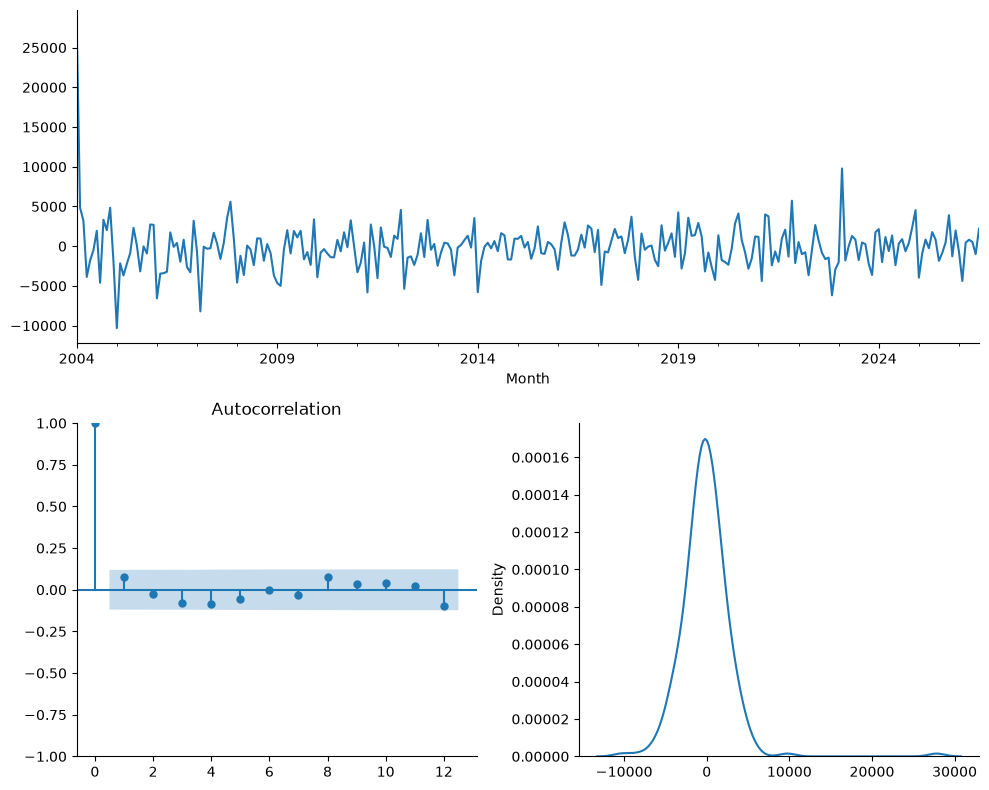

** Mean of the residuals:  -148.48

** Jarque Bera Normality Test, p_value: 0.0 (<0.05, Not-normal)

** AD Fuller, p_value: 0.0 (<0.05, Stationary)

** Test de ARCH-LM, p_value: 0.3632 (>0.05, homocedastic)


(<Axes: xlabel='Month'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: ylabel='Density'>)

In [30]:
residcheck(arima_3.resid, 12)

Los resultados indican que la media de los residuos es de $-148.48\text{ GWh}$, un valor prácticamente despreciable en comparación con la magnitud del consumo medio mensual (superior a los $30.000\text{ GWh}$), confirmando la insesgadez del ajuste. Asimismo, el test de Dickey-Fuller Aumentado $(p\text{-valor} = 0.000)$ corrobora que las perturbaciones son estrictamente estacionarias en media.

El contraste de Jarque-Bera $(p\text{-valor} = 0.000)$ rechaza la hipótesis de normalidad esto no invalida el modelo: se sigue garantizando la condición de ruido blanco débil (media cero, incorrelación temporal y varianza constante), suficiente para asegurar la validez asintótica de las estimaciones y las propiedades óptimas de los pronósticos.

Por último, el test ARCH-LM $(p\text{-valor} = 0.3632 > 0.05)$, evaluado descartando los primeros 13 periodos para mitigar el efecto transitorio de inicialización derivado de la diferenciación estacional y regular $(d=1, D=1, s=12)$, ratifica la homocedasticidad condicional de las perturbaciones. Esta estabilidad dinámica complementa la homocedasticidad global demostrada previamente en el resumen, validando por completo la hipótesis de varianza constante requerida en el proceso de perturbación.

A continuación, se evalúan en detalle los correlogramas (ACF y PACF) y la tabla de contrastes de Ljung-Box retardo a retardo para verificar la ausencia individual de dependencia serial.

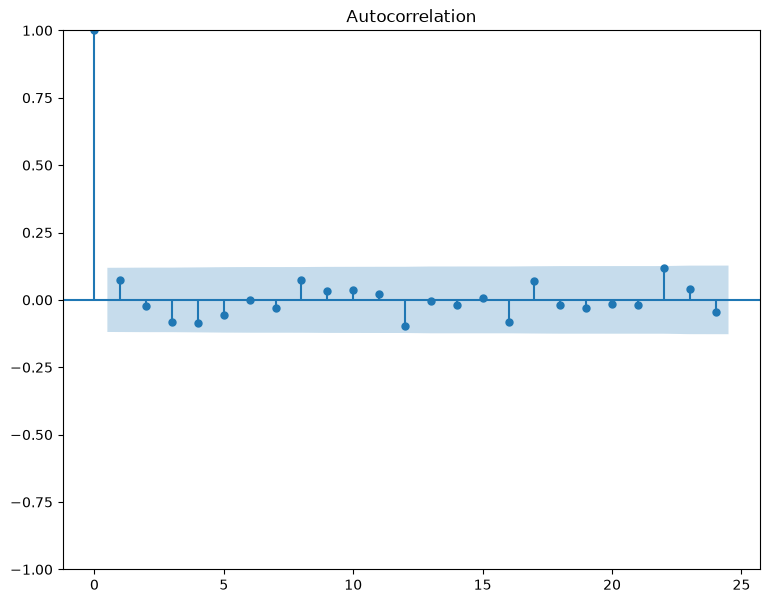

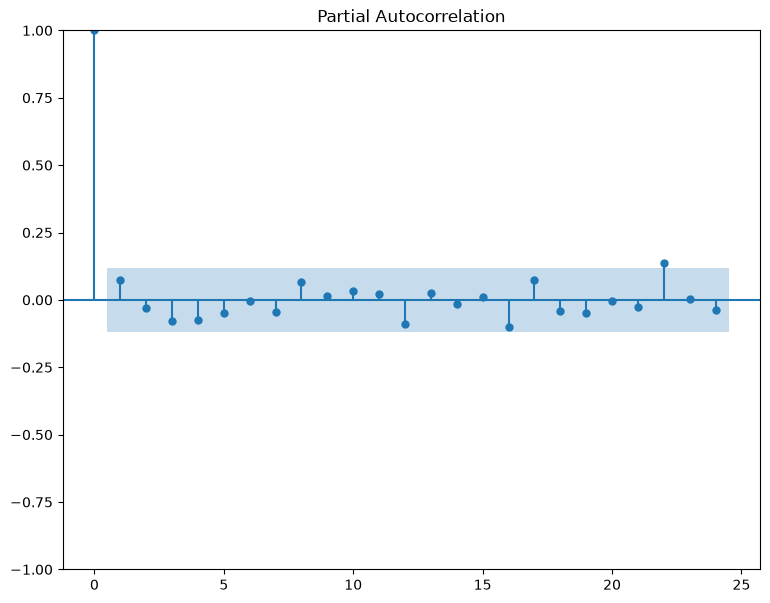

In [31]:
plot_acf(arima_3.resid,lags=24)
plt.show()
plot_pacf(arima_3.resid,lags=24,method='ywm')
plt.show()

La inspección visual de las funciones de autocorrelación simple (ACF) y parcial (PACF) de los residuos a lo largo de 24 retardos (dos ciclos anuales completos) ratifica la ausencia de correlación serial. La práctica totalidad de las autocorrelaciones se sitúa holgadamente dentro de las bandas de confianza del $95\%$, sin mostrar patrones sistemáticos en los retardos regulares ni en los estacionales $(s = 12, 24)$. La fluctuación marginal observada en el retardo 22 carece de interpretación económica y responde a la variabilidad muestral esperable bajo un nivel de confianza del $95\%$.

In [32]:
sm.stats.acorr_ljungbox(arima_3.resid, lags=24, return_df=True)

,lb_stat,lb_pvalue
1,1.498825,0.220852
2,1.660457,0.435950
3,3.436840,0.329047
4,5.509003,0.238939
5,6.393172,0.269819
6,6.394105,0.380519
7,6.623037,0.469154
8,8.232780,0.411068
9,8.538329,0.480933
10,8.946935,0.537147


Asimismo, al evaluar la evolución secuencial del test de Ljung-Box a lo largo de los 24 retardos dos ciclos anuales, se constata que los $p$-valores superan en todo momento el nivel de significación del $5\%$ $(\alpha = 0.05)$, oscilando entre $0.221$ y $0.780$. 

Esta evidencia empírica confirma la ausencia de autocorrelación serial acumulada paso a paso, ratificando de manera concluyente que las perturbaciones del modelo $\text{SARIMA}(0,1,1)(0,1,1)_{12}$ constituyen un proceso de ruido blanco. Cumplidos satisfactoriamente todos los criterios de diagnosis, el modelo queda plenamente validado para la fase final de predicción y análisis de escenarios.

#### Ecuación estimada definitiva ($T = 271$, 2004–2026): 

$$(1 - B)(1 - B^{12}) y_t = (1 - 0.2449 B)(1 - 0.7834 B^{12}) \hat{\varepsilon}_t$$

Forma desarrollada para el cálculo recursivo de valores en niveles:

$$y_t = y_{t-1} + y_{t-12} - y_{t-13} + \hat{\varepsilon}_t - 0.2449 \hat{\varepsilon}_{t-1} - 0.7834 \hat{\varepsilon}_{t-12} + 0.1919 \hat{\varepsilon}_{t-13}$$

# 4. Predicción y Proyecciones Futuras

Habiendo validado tanto la bondad de ajuste sobre la muestra histórica completa ($T = 271$, 2004–2026) como la robustez de sus errores fuera de muestra en la validación temporal previa (MAPE promedio de 9.86%), se procede a utilizar la especificación seleccionada **SARIMA$(0, 1, 1)(0, 1, 1)_{12}$** para generar las trayectorias prospectivas del consumo de gas natural.

En esta fase se proyecta el horizonte temporal futuro, calculando tanto las estimaciones puntuales como sus correspondientes intervalos de confianza para cuantificar la incertidumbre del pronóstico.

In [33]:
pred = arima_3.get_forecast(steps = 12)
df_pred = pred.summary_frame(alpha = 0.05).round(2)
df_pred.columns = ['Forecast', 'SE', '95% LB', '95% UB']
df_pred

,Forecast,SE,95% LB,95% UB
2026-08-01,25213.68,2295.12,20715.33,29712.03
2026-09-01,26100.59,2876.00,20463.73,31737.45
2026-10-01,27512.01,3357.85,20930.74,34093.29
2026-11-01,30764.07,3778.75,23357.85,38170.29
2026-12-01,33599.32,4157.26,25451.25,41747.40
2027-01-01,35019.72,4504.06,26191.92,43847.52
2027-02-01,30068.14,4826.01,20609.33,39526.95
2027-03-01,29172.68,5127.79,19122.40,39222.95
2027-04-01,24973.47,5412.76,14364.66,35582.29
2027-05-01,24919.41,5683.47,13780.02,36058.80


En el diagnóstico previo de los residuos, el contraste de Jarque-Bera rechazó la hipótesis de normalidad debido a la presencia de perturbaciones atípicas y colas pesadas. En consecuencia, los intervalos de confianza analíticos tradicionales derivados bajo supuestos gaussianos (presentados en la tabla superior) podrían subestimar la dispersión en las colas.

Para cuantificar la incertidumbre prospectiva con mayor precisión empírica, se implementa una simulación por remuestreo no paramétrico (*bootstrap residual*). Mediante 1000 trayectorias proyectadas con reemplazo a partir de los errores observados, se extraen empíricamente los percentiles 2,5 y 97,5. Este procedimiento permite construir intervalos de predicción al 95% robustos ante asimetrías y curtosis, evitando infravalorar el riesgo en escenarios extremos de alta y baja demanda.

In [34]:
# Fijar semilla
rng = np.random.default_rng(2026)

# 2. Simulación de errores acumulados vía Bootstrap para estimar las bandas empíricas
n_sims = 1000
n_steps = 12
residuos = (arima_3.resid.dropna() - arima_3.resid.mean()).values

trayectorias = np.zeros((n_steps, n_sims))
for b in range(n_sims):
    shocks = rng.choice(residuos, size=n_steps, replace=True).reshape(n_steps, 1)
    trayectorias[:, b] = arima_3.simulate(nsimulations=n_steps, anchor='end', state_shocks=shocks, random_state=rng)

# 3. Extraer ÚNICAMENTE las bandas empíricas (el intervalo)
ic_inf_bootstrap = pd.Series(np.percentile(trayectorias, 2.5, axis=1), index=df_pred.index)
ic_sup_bootstrap = pd.Series(np.percentile(trayectorias, 97.5, axis=1), index=df_pred.index)

print(ic_inf_bootstrap)
print(ic_sup_bootstrap)

2026-08-01    20580.133337
2026-09-01    20152.062031
2026-10-01    20491.059451
2026-11-01    23661.993738
2026-12-01    24740.485920
2027-01-01    25084.042576
2027-02-01    19942.129856
2027-03-01    18068.059727
2027-04-01    12327.811823
2027-05-01    12301.220757
2027-06-01    12397.738779
2027-07-01    13662.989068
Freq: MS, dtype: float64
2026-08-01    29816.998684
2026-09-01    31651.627094
2026-10-01    34565.418783
2026-11-01    38664.228502
2026-12-01    42990.351951
2027-01-01    45667.712054
2027-02-01    42926.580019
2027-03-01    43717.434621
2027-04-01    40209.824173
2027-05-01    40635.568513
2027-06-01    42099.973948
2027-07-01    46529.793447
Freq: MS, dtype: float64


In [35]:
df_pred_futura = pd.DataFrame({
    'Forecast': df_pred['Forecast'],
    'SE': df_pred['SE'],
    'LB_Gaussiano': df_pred['95% LB'],
    'UB_Gaussiano': df_pred['95% UB'],
    'LB_Bootstrap': ic_inf_bootstrap.round(2),
    'UB_Bootstrap': ic_sup_bootstrap.round(2)
})

df_pred_futura

,Forecast,SE,LB_Gaussiano,UB_Gaussiano,LB_Bootstrap,UB_Bootstrap
2026-08-01,25213.68,2295.12,20715.33,29712.03,20580.13,29817.00
2026-09-01,26100.59,2876.00,20463.73,31737.45,20152.06,31651.63
2026-10-01,27512.01,3357.85,20930.74,34093.29,20491.06,34565.42
2026-11-01,30764.07,3778.75,23357.85,38170.29,23661.99,38664.23
2026-12-01,33599.32,4157.26,25451.25,41747.40,24740.49,42990.35
2027-01-01,35019.72,4504.06,26191.92,43847.52,25084.04,45667.71
2027-02-01,30068.14,4826.01,20609.33,39526.95,19942.13,42926.58
2027-03-01,29172.68,5127.79,19122.40,39222.95,18068.06,43717.43
2027-04-01,24973.47,5412.76,14364.66,35582.29,12327.81,40209.82
2027-05-01,24919.41,5683.47,13780.02,36058.80,12301.22,40635.57


En la tabla anterior se presentan las proyecciones puntuales mensuales junto con su error estándar $(\text{SE})$ y los intervalos de predicción al 95% para un horizonte prospectivo de 12 meses (agosto de 2026 a julio de 2027), contrastando la aproximación analítica gaussiana frente a la empírica por *bootstrap*. Como se observa, el remuestreo genera bandas ligeramente más amplias en ambas colas, incorporando adecuadamente el riesgo de perturbaciones extremas detectado en la diagnosis.

La trayectoria estimada replica con fidelidad la dinámica estacional característica de la demanda de gas:

* Ciclo estacional: Se proyecta un incremento sostenido a partir del otoño hasta alcanzar el pico invernal en enero de 2027 $(35\,019.72\text{ GWh})$, seguido de una contracción paulatina hacia los valles de primavera y verano (en torno a los $24\,900\text{ GWh}$).
* Evolución de la incertidumbre: En consonancia con la teoría de procesos integrados ($d = 1, D = 1$), el error estándar de predicción se expande de manera monótona a medida que se amplía el horizonte temporal (desde $2\,295.12$ en el primer mes hasta $6\,189.46$ en el mes 12), reflejando la acumulación natural de incertidumbre en las trayectorias no estacionarias a medio plazo.

### Análisis e interpretación gráfica de las proyecciones

A continuación, se representan gráficamente las proyecciones puntuales integrando las bandas de confianza al 95% obtenidas por *bootstrap*, contrastándolas con el histórico de los últimos 5 años para evaluar su coherencia estructural.

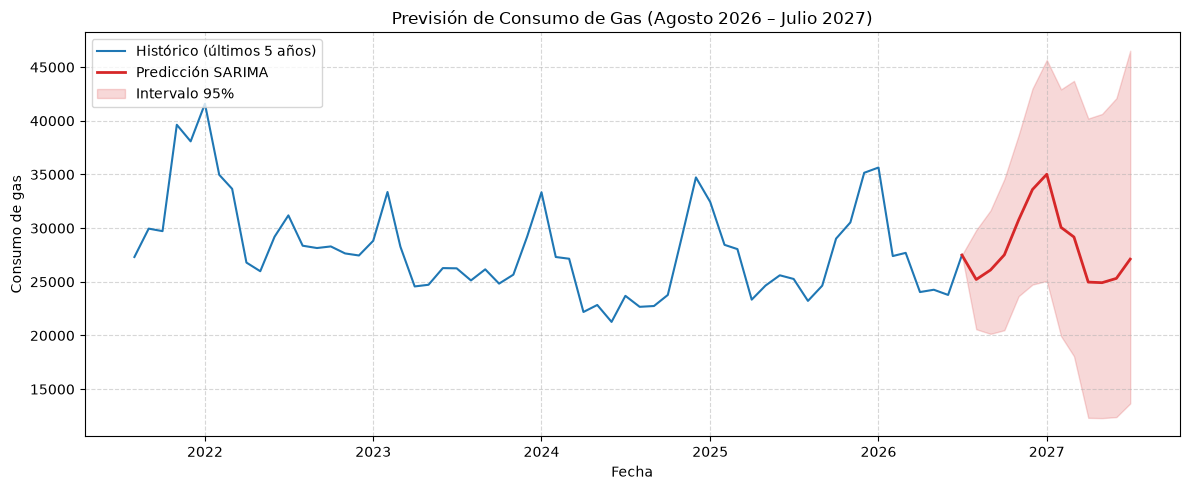

In [36]:
# 1. Crear una pequeña serie puente con el último punto real + la predicción
ultimo_punto = df_gas['gas_consumption'].iloc[-1:]  # Julio 2026
pred_continua = pd.concat([ultimo_punto, df_pred_futura['Forecast']])

# Para la banda de confianza también incluimos el último punto (con ancho cero al inicio)
ci_lower_continua = pd.concat([ultimo_punto, df_pred_futura['LB_Bootstrap']])
ci_upper_continua = pd.concat([ultimo_punto, df_pred_futura['UB_Bootstrap']])

# 2. Graficar con zoom en los últimos 5 años 
plt.figure(figsize=(12, 5))

# Histórico reciente
plt.plot(df_gas.index[-60:], df_gas['gas_consumption'].iloc[-60:], label='Histórico (últimos 5 años)', color='#1f77b4', lw=1.5)

# Predicción perfectamente unida
plt.plot(pred_continua.index, pred_continua.values, label='Predicción SARIMA', color='#d62728', lw=2)

# Sombra conectada desde el último valor real
plt.fill_between(
    ci_lower_continua.index,
    ci_lower_continua.values,
    ci_upper_continua.values,
    color='#d62728',
    alpha=0.18,
    label='Intervalo 95%'
)

plt.title("Previsión de Consumo de Gas (Agosto 2026 – Julio 2027)")
plt.ylabel('Consumo de gas')
plt.xlabel('Fecha')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()

# Guardar la imagen en la raíz del proyecto para el README
plt.savefig('../gas_forecast_sarima.png', dpi=300, bbox_inches='tight')

plt.show()

In [1]:

# Guardado asi para que no genere imagenes todo el rato
import os
print(os.path.abspath('../gas_forecast_sarima.png'))


C:\Users\diego\OneDrive\Escritorio\gas_forecast_sarima.png


El gráfico anterior ilustra el empalme entre la trayectoria observada en los últimos 5 años y las proyecciones puntuales acompañadas de sus bandas de incertidumbre al 95%:

* Consistencia estacional: El modelo SARIMA(0, 1, 1)(0, 1, 1)₁₂ replica con exactitud el ciclo intraanual de la demanda gasista, anticipando el inicio del repunte térmico en otoño, un pico invernal centrado en enero de 2027 y la posterior estabilización estival en niveles similares a los ejercicios precedentes.
* Comportamiento del nivel medio: En consonancia con la ausencia de una deriva determinista en la especificación integrada, la previsión no proyecta variaciones tendenciales explosivas, sino una consolidación moderada de los volúmenes de consumo en torno a los promedios observados entre 2024 y 2026.
* Banda de incertidumbre: Como es característico en los procesos con doble orden de integración ($d = 1, D = 1$), el abanico del intervalo de confianza se expande progresivamente hacia el final del horizonte, delimitando un rango de variación entre aproximadamente 12 000 y 46 000 GWh para cubrir escenarios extremos de volatilidad climática o perturbaciones en los mercados energéticos.

## 5. Conclusiones

La modelización econométrica de la demanda de gas natural en España a partir de las series históricas de CORES confirma la idoneidad empírica de la metodología Box-Jenkins para capturar la dinámica estacional del sistema energético. La estabilidad inicial de la varianza en niveles (contrastada mediante el test de Bartlett, $p > 0.05$) descartó transformaciones no lineales, mientras que la combinación de una diferenciación estacional ($D = 1, s = 12$) y una regular ($d = 1$) garantizó la estacionariedad estricta de la serie según los contrastes de Dickey-Fuller aumentado.

Siguiendo una estrategia de reducción *general-to-specific*, se descartaron los coeficientes no significativos del modelo sobredimensionado inicial hasta converger en la especificación **SARIMA(0, 1, 1)(0, 1, 1)₁₂**. Este modelo ratificó plenamente el principio de parsimonia al minimizar el criterio bayesiano (**BIC = 4752.73**) y registrar un error fuera de muestra altamente competitivo (MAPE = 5.08% en el ciclo reciente y 10.05% de promedio). La reestimación sobre el conjunto total de observaciones ($T = 271$) validó que los residuos satisfacen de manera estricta las hipótesis de ruido blanco débil: media nula, ausencia de autocorrelación serial (Ljung-Box, $p > 0.05$) y homocedasticidad condicional (ARCH-LM, $p = 0.3632$).

Las proyecciones generadas para el ciclo agosto 2026 – julio 2027 capturan con precisión la estacionalidad del mercado español, anticipando el pico de consumo en enero de 2027 (35 019.72 GWh) y valles estivales estables en torno a los 24 900 GWh. Los intervalos de predicción no paramétricos al 95% obtenidos vía *bootstrap* proporcionan un marco cuantitativo robusto frente a perturbaciones atípicas, convirtiendo a este modelo en una herramienta operativa sólida para la planificación logística, la gestión de almacenamientos subterráneos y el aprovisionamiento de gas natural.

## 6. Bibliografía

* Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5.ª ed.). John Wiley & Sons.
* Brown, R. L., Durbin, J., & Evans, J. M. (1975). Techniques for testing the constancy of regression relationships over time. *Journal of the Royal Statistical Society: Series B (Methodological)*, 37(2), 149-163.
* CORES (2026). *Estadísticas de consumo de gas natural en España (2004–2026)*. Corporación de Reservas Estratégicas de Productos Petrolíferos.
* Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association*, 74(366), 427-431.
* Efron, B., & Tibshirani, R. J. (1994). *An Introduction to the Bootstrap*. Chapman & Hall/CRC.
* Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. *Econometrica*, 50(4), 987-1007.
* Hamilton, J. D. (1994). *Time Series Analysis*. Princeton University Press.
* Harvey, A. C. (1989). *Forecasting, Structural Time Series Models and the Kalman Filter*. Cambridge University Press.
* Jarque, C. M., & Bera, A. K. (1987). A test for normality of observations and regression residuals. *International Statistical Review*, 55(2), 163-172.
* Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time series models. *Biometrika*, 65(2), 297-303.
* Pankratz, A. (1983). *Forecasting with Univariate Box-Jenkins Models: Concepts and Cases*. John Wiley & Sons.
* Peña Sánchez-Rivera, D. (2010). *Análisis de series temporales*. Alianza Editorial.